# ANN Regression

First of all, notice that we are not predicting every single data point here in its entirety. That is not our goal here. Our goal here is to have a simplified representation of the important features of this dataset. And the important feature of this dataset is the positive correlation between variable x and variable y.

That's the key thing we want to capture. If you wanted to capture all of these little divergences here, first of all, I'm not really sure that that would be a good idea anyway, because that is getting dangerously close to overfitting the data, and overfitting the data is a major issue.

![alt text](img/ann-for-regression-1.png)

The second thing I would like to point out is that it looks at first, at first glance it looks like our predictions here are a line, a straight line cutting through the data, but actually if you look at the data more closely, you can see it's not a perfect line.

And that's most visible when you get out to this point here (to the far right, the red square about about (2.0,1.3)). We have non-linearity in the model which allows it to fall off of the straight line. 

The model we will construct:

![alt text](img/ann-for-regression-2.png)

We wil use MSE because we're making continuous predictions of numerical values. 

C:\Users\mpere\AppData\Local\Temp\ipykernel_30340\1701953524.py:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


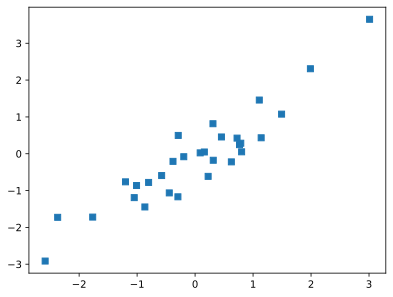

In [33]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt 
from IPython import display
display.set_matplotlib_formats('svg')

# create data
N = 30
x = torch.randn(N,1)  # Generate some random data
y = x + torch.randn(N,1)/2 # more random data but add to the top of x's random data

plt.plot(x,y,'s')
plt.show()




In [34]:
# build the model
ANNreg = nn.Sequential(
    nn.Linear(1,1), #input layer (# of Inputs, # of Outputs) where # of Inputs = x values amd # Of Outputs = 1 which is input to outputlayer
    nn.ReLU(), # activation fcn. Rectified Linear Unit
    nn.Linear(1,1)  #output layer
)
ANNreg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [35]:
# learning rate
learningRate =  0.05

# loss function
lossfcn = nn.MSELoss() # object class that will implement the MSELOss fcn for us. 

# optimzer (the falvor of gradient descent to implement)
optimizer = torch.optim.SGD(ANNreg.parameters(),lr=learningRate) #stochastic GD


In [36]:
# train the model
numepochs = 500
losses = torch.zeros(numepochs)

## Train the model!
for epochi in range(numepochs):

    # forward pass
    yHat = ANNreg(x)

    # compute loss. recall we using MSE (the squared diff ..)
    loss = lossfcn(yHat,y) #predicted and observed (reality)
    losses[epochi] = loss # for grapning so we need a trail of losses and where they occurred

    #backprop
    optimizer.zero_grad()
    loss.backward() # runs backprop based on the losses we experienced from the lossfcn() call
    optimizer.step()




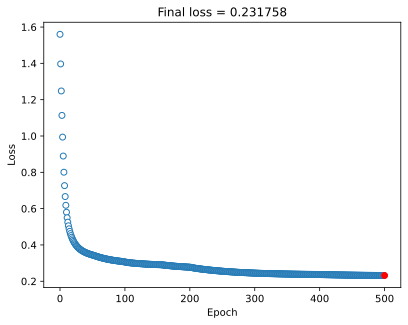

In [37]:
# show the losses

# manually compute losses
# final forward pass. Running another foward pass but we're now calling it predictions instead of yHat!
predictions = ANNreg(x)

# final loss (MSE). Running our own

testloss = (predictions-y).pow(2).mean() # take the average over all of the individual square differences

plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.plot(numepochs,testloss.detach(),'ro')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final loss = %g' %testloss.item())
plt.show()



It looks like we didn't actually need to train 500 epochs, probably somewhere around 200 epochs would've been sufficient. The loss is quite small, and it's not really getting any smaller, which means that the model is really finished learning.

But for plotting, for visualization, we actually want to ignore all this other information. We just want to get out these specific numbers. So you can do that by using detach, and that essentially detaches the number from all the other information. So that's just this tensor. And depending on the data type and the variable size, you can also use item, which just gives you the actual number itself, separate from it being stored as a tensor. And depending on the data type and the variable size, you can also use item,
which just gives you the actual number itself, separate from it being stored as a tensor.

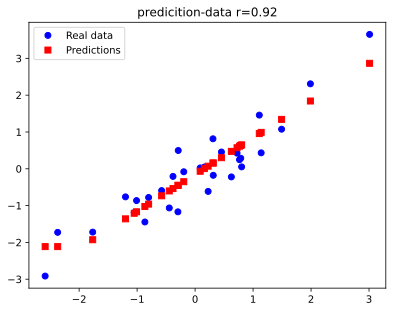

In [38]:
# testloss # a PyTorch tensor w/a gradient fcn attache named grad_fn
plt.plot(x,y,'bo',label='Real data')
plt.plot(x,predictions.detach(),'rs',label='Predictions')
plt.title(f'predicition-data r={np.corrcoef(y.T,predictions.detach().T)[0,1]:.2f}')
plt.legend()
plt.show()


![alt text](img/ann-for-regression-3.png)